In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/competitions/spaceship-titanic/sample_submission.csv
/kaggle/input/competitions/spaceship-titanic/train.csv
/kaggle/input/competitions/spaceship-titanic/test.csv


In [2]:
df_train = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/test.csv')

print('Train df shape:', df_train.shape)
print('Test df shape:', df_test.shape)

df_train.head()

Train df shape: (8693, 14)
Test df shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
#Após analisar os dados e os feedbacks, a melhor decisão para especificar as informações foi separar a coluna 'Cabin' em 'Deck', 'CabinNum' e 'Side' 
#(deck/num/side) usando o separador '/'. Como as colunas 'Cabin' e 'CabinNum' não serão mais úteis após essa extração, elas foram removidas.
df_train[['Deck', 'Num', 'Side']] = df_train['Cabin'].str.split('/', expand=True)
df_train.drop(['Cabin','Num'],axis=1,inplace=True)
df_test[['Deck', 'Num', 'Side']] = df_test['Cabin'].str.split('/', expand=True)
df_test.drop(['Cabin','Num'],axis=1,inplace=True)

In [4]:
#informaçao a respeito das colunas
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Destination   8511 non-null   object 
 4   Age           8514 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8512 non-null   float64
 7   FoodCourt     8510 non-null   float64
 8   ShoppingMall  8485 non-null   float64
 9   Spa           8510 non-null   float64
 10  VRDeck        8505 non-null   float64
 11  Name          8493 non-null   object 
 12  Transported   8693 non-null   bool   
 13  Deck          8494 non-null   object 
 14  Side          8494 non-null   object 
dtypes: bool(1), float64(6), object(8)
memory usage: 959.4+ KB


In [5]:
#quantos valores únicos existem
df_train.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
Deck               8
Side               2
dtype: int64

In [6]:
#quantos valores nulos existem
df_train.isnull().sum() 

PassengerId       0
HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Deck            199
Side            199
dtype: int64

**Começa aqui a limpeza e tratamento dos dados**

In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Destination   4185 non-null   object 
 4   Age           4186 non-null   float64
 5   VIP           4184 non-null   object 
 6   RoomService   4195 non-null   float64
 7   FoodCourt     4171 non-null   float64
 8   ShoppingMall  4179 non-null   float64
 9   Spa           4176 non-null   float64
 10  VRDeck        4197 non-null   float64
 11  Name          4183 non-null   object 
 12  Deck          4177 non-null   object 
 13  Side          4177 non-null   object 
dtypes: float64(6), object(8)
memory usage: 467.9+ KB


In [8]:
#Transforma o boolean com True ou false em inteiros com 0 e 1(para facilitar leitura dos modelos)
df_train["Transported"] = df_train["Transported"].astype(int)

In [9]:
#Separa e guarda as colunas por tipo: Objeto e Float64(númerica)
cat_cols = df_train.select_dtypes(include=['object']).columns
num_cols = df_train.select_dtypes(include=['float64']).columns


# Busca a moda das colunas categóricas. Usa-se .iloc[0] pois o .mode() retorna um DataFrame/Series
cat_impute_values = df_train[cat_cols].mode().iloc[0]

#Preenche colunas categóricas com a Moda
df_train[cat_cols] = df_train[cat_cols].fillna(cat_impute_values)
df_test[cat_cols] = df_test[cat_cols].fillna(cat_impute_values)

#Busca a média das colunas numéricas.
num_impute_values = df_train[num_cols].mean()

#Preenche colunas numéricas com a Média dos valores
df_train[num_cols] = df_train[num_cols].fillna(num_impute_values)
df_test[num_cols] = df_test[num_cols].fillna(num_impute_values)

/tmp/ipykernel_17/2065862766.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train[cat_cols] = df_train[cat_cols].fillna(cat_impute_values)
/tmp/ipykernel_17/2065862766.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[cat_cols] = df_test[cat_cols].fillna(cat_impute_values)


In [10]:
#Transforma o boolean com True ou false em inteiros com 0 e 1(para facilitar leitura dos modelos)
df_train["VIP"] = df_train["VIP"].astype(int)
df_test["VIP"] = df_test["VIP"].astype(int)

df_train["CryoSleep"] = df_train["CryoSleep"].astype(int)
df_test["CryoSleep"] = df_test["CryoSleep"].astype(int)

In [11]:
#Eu cogitei separar os tripulantes por idade também, criando labels por idade, por exemplo: entre 0 até 10 anos é criança, entre 11 e 17 é adolescente,
#etc... Mas desisti da idéia. Depois posso testar isto para comparar métricas e resultados.

#Tratamento de valores ausentes de IDADE e conversão para float
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].mode()[0]).astype(float)
df_test['Age'] = df_test['Age'].fillna(df_test['Age'].mode()[0]).astype(float)

In [12]:
df_train.isnull().sum() #0 valores nulos, está clean demais

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
Deck            0
Side            0
dtype: int64

In [13]:
df_test.isnull().sum() #0 valores nulos, está clean demais

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Deck            0
Side            0
dtype: int64

In [14]:
#Remover as colunas não necessárias para treinamento e teste
df_train.drop(['Name','PassengerId'],axis=1,inplace=True)
df_test.drop(['Name'],axis=1,inplace=True)

**Um pouco de EDA** 

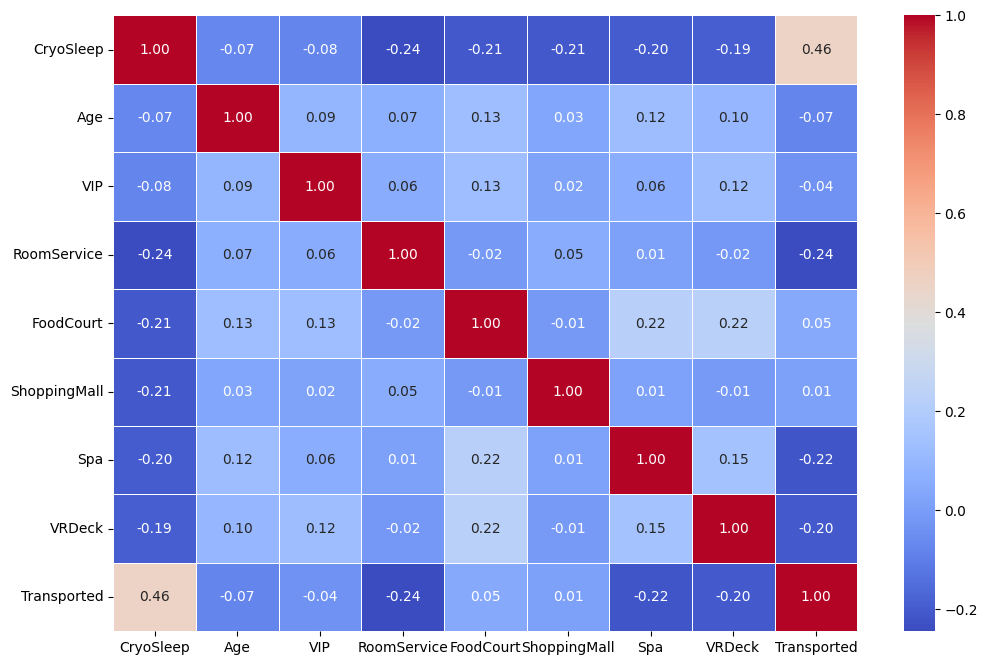

In [15]:
#Matriz de correlação entre variaveis numéricas
corr_matrix = df_train.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

<Axes: xlabel='count', ylabel='HomePlanet'>

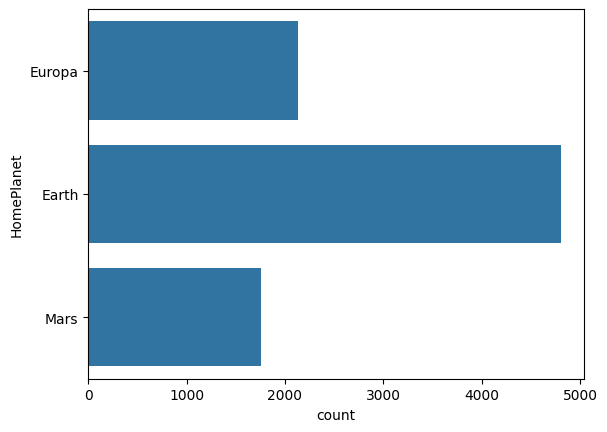

In [16]:
#De quais planetas são os tripulantes
sns.countplot(data=df_train['HomePlanet'])

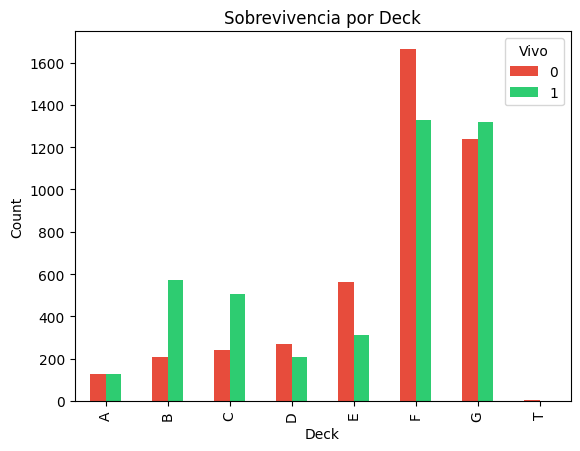

In [17]:
#Relação sobreviventes por Deck
ct = pd.crosstab(df_train['Deck'], df_train['Transported'])
ct.plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.xlabel('Deck')
plt.ylabel('Count')
plt.title('Sobrevivencia por Deck')
plt.legend(title='Vivo')
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

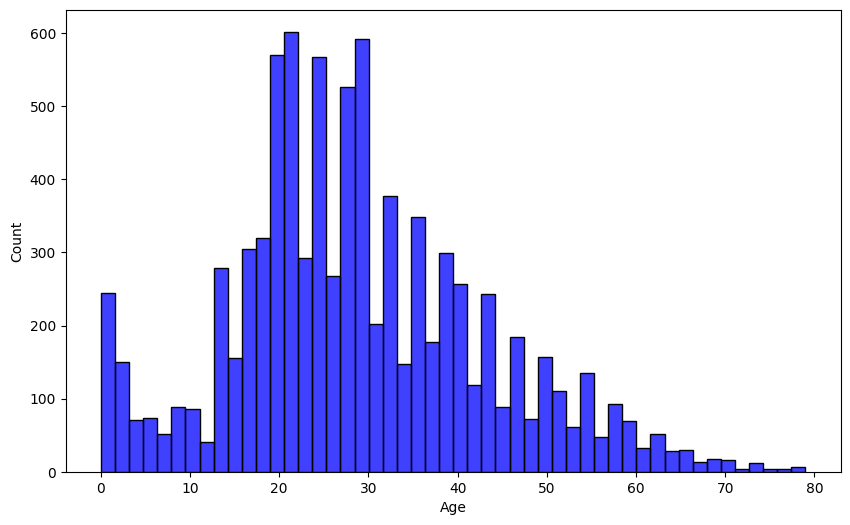

In [18]:
#Idades
plt.figure(figsize=(10, 6))


sns.histplot(df_train['Age'], color='b', bins=50)

In [19]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8693 non-null   object 
 1   CryoSleep     8693 non-null   int64  
 2   Destination   8693 non-null   object 
 3   Age           8693 non-null   float64
 4   VIP           8693 non-null   int64  
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Transported   8693 non-null   int64  
 11  Deck          8693 non-null   object 
 12  Side          8693 non-null   object 
dtypes: float64(6), int64(3), object(4)
memory usage: 883.0+ KB


In [20]:
#Agora precisamos transformar as palavras (texto) em números, para que o modelo consiga processar os dados.
#Exemplo: Coluna "HomePlanet": Earth → 0, Europa → 1,Mars → 2

#Seleciona as colunas que tem palavras
obj_cols = df_train.select_dtypes(include='object').columns
#Enconder escolhido após estudo+Feedback
encoder = OrdinalEncoder()
#Enconder faz a transformação mostrada no exemplo
df_train[obj_cols] = encoder.fit_transform(df_train[obj_cols])
df_test[obj_cols]=encoder.transform(df_test[obj_cols])

In [21]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4277 non-null   float64
 2   CryoSleep     4277 non-null   int64  
 3   Destination   4277 non-null   float64
 4   Age           4277 non-null   float64
 5   VIP           4277 non-null   int64  
 6   RoomService   4277 non-null   float64
 7   FoodCourt     4277 non-null   float64
 8   ShoppingMall  4277 non-null   float64
 9   Spa           4277 non-null   float64
 10  VRDeck        4277 non-null   float64
 11  Deck          4277 non-null   float64
 12  Side          4277 non-null   float64
dtypes: float64(10), int64(2), object(1)
memory usage: 434.5+ KB


In [22]:
df_test.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,Side
0,0013_01,0.0,1,2.0,27.0,0,0.0,0.0,0.0,0.0,0.0,6.0,1.0
1,0018_01,0.0,0,2.0,19.0,0,0.0,9.0,0.0,2823.0,0.0,5.0,1.0
2,0019_01,1.0,1,0.0,31.0,0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
3,0021_01,1.0,0,2.0,38.0,0,0.0,6652.0,0.0,181.0,585.0,2.0,1.0
4,0023_01,0.0,0,2.0,20.0,0,10.0,0.0,635.0,0.0,0.0,5.0,1.0


In [23]:
#Agora vamos separar os grupos para o treino e teste

# X = Variáveis Independentes | Y = Variável dependente
ytrain = df_train["Transported"]
xtrain = df_train.drop("Transported", axis=1)

#Eu cogitei em normalizar algumas colunas com valores monetários aqui, como por exemplo: RoomService, FoodCourt, etc... mas decidi não fazer isto pois são poucos valores
#Talvez depois eu mude de idéia se o resultado não for satisfatório

In [24]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8693 non-null   float64
 1   CryoSleep     8693 non-null   int64  
 2   Destination   8693 non-null   float64
 3   Age           8693 non-null   float64
 4   VIP           8693 non-null   int64  
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Transported   8693 non-null   int64  
 11  Deck          8693 non-null   float64
 12  Side          8693 non-null   float64
dtypes: float64(10), int64(3)
memory usage: 883.0 KB


In [25]:
df_train.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Side
0,1.0,0,2.0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,1.0,0.0
1,0.0,0,2.0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,5.0,1.0
2,1.0,0,2.0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,0.0,1.0
3,1.0,0,2.0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,0.0,1.0
4,0.0,0,2.0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,5.0,1.0


In [26]:
#Separa os dados para treino e teste
x_train, x_test, y_train, y_test = train_test_split(xtrain, ytrain, test_size=0.2, random_state=42)

In [27]:

rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train, y_train)        


RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

# Vendo o resultado com um modelo de boosting
gb = GradientBoostingClassifier(n_estimators=200, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42)
gb.fit(x_train, y_train)

GradientBoostingClassifier(n_estimators=200, random_state=42)

**Comparação de performance e resultado dos modelos RandomForestClassifier e GradientBoostingClassifier**

In [29]:
from sklearn.metrics import accuracy_score, roc_auc_score
def avaliar_modelo(nome, modelo, x_test, y_test):
    y_pred = modelo.predict(x_test)
    y_proba = modelo.predict_proba(x_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    print(f"--- {nome} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC:      {auc:.4f}\n")
    return acc, auc
rf_acc,rf_auc = avaliar_modelo("Random Forest", rf, x_test, y_test)
gb_acc,gb_auc = avaliar_modelo("Gradient Boosting", gb, x_test, y_test)

--- Random Forest ---
Accuracy: 0.7872
AUC:      0.8765

--- Gradient Boosting ---
Accuracy: 0.7878
AUC:      0.8809



In [30]:
print(f"Random Forest: Accuracy {rf_acc:.4f} | AUC {rf_auc:.4f}")
print(f"Gradient Boosting: Accuracy {gb_acc:.4f} | AUC {gb_auc:.4f}")

Random Forest: Accuracy 0.7872 | AUC 0.8765
Gradient Boosting: Accuracy 0.7878 | AUC 0.8809


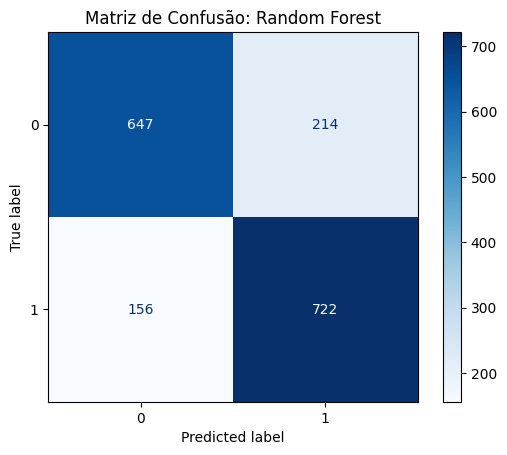

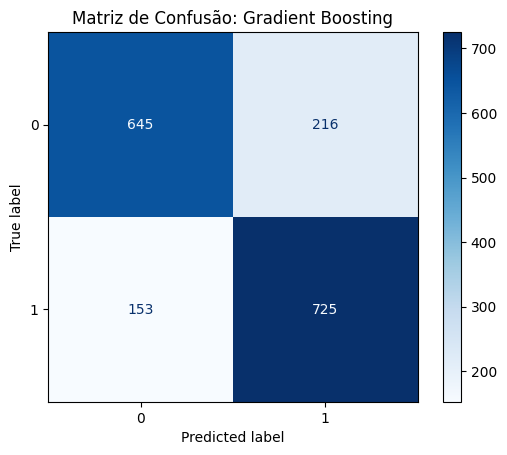

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plotar_matriz(nome, modelo, x_test, y_test):
    y_pred = modelo.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusão: {nome}')
    plt.show()

plotar_matriz("Random Forest", rf, x_test, y_test)
plotar_matriz("Gradient Boosting", gb, x_test, y_test)

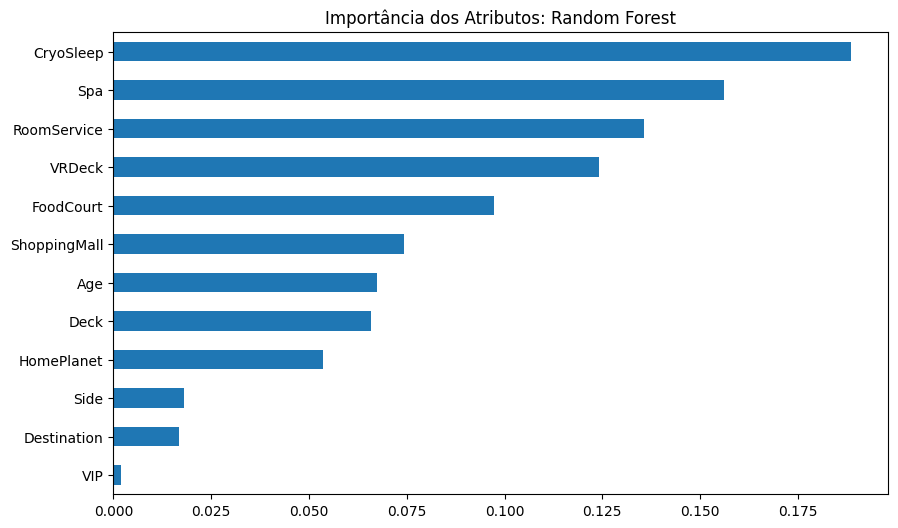

In [32]:
def plotar_importancia(nome, modelo, x_train):
    importancias = pd.Series(modelo.feature_importances_, index=x_train.columns)
    importancias = importancias.sort_values(ascending=True)
    
    plt.figure(figsize=(10, 6))
    importancias.plot(kind='barh')
    plt.title(f'Importância dos Atributos: {nome}')
    plt.show()

plotar_importancia("Random Forest", rf, x_train)

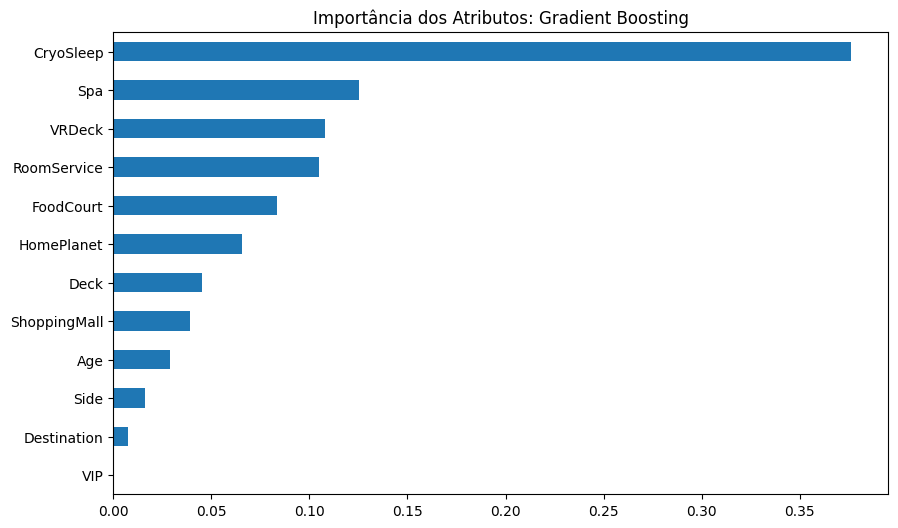

In [33]:
def plotar_importancia(nome, modelo, x_train):
    importancias = pd.Series(modelo.feature_importances_, index=x_train.columns)
    importancias = importancias.sort_values(ascending=True)
    
    plt.figure(figsize=(10, 6))
    importancias.plot(kind='barh')
    plt.title(f'Importância dos Atributos: {nome}')
    plt.show()

plotar_importancia("Gradient Boosting", gb, x_train)

**Fase final Submissão: Prever os dados de teste com a rede neural que obteve as melhores métricas e submeter em um novo arquivo**

In [34]:
df_test.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,Side
0,0013_01,0.0,1,2.0,27.0,0,0.0,0.0,0.0,0.0,0.0,6.0,1.0
1,0018_01,0.0,0,2.0,19.0,0,0.0,9.0,0.0,2823.0,0.0,5.0,1.0
2,0019_01,1.0,1,0.0,31.0,0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
3,0021_01,1.0,0,2.0,38.0,0,0.0,6652.0,0.0,181.0,585.0,2.0,1.0
4,0023_01,0.0,0,2.0,20.0,0,10.0,0.0,635.0,0.0,0.0,5.0,1.0


In [35]:
#É escolhido o modelo com a melhor accuracy
melhor_modelo = gb if gb_acc > rf_acc else rf
print(f"Usando o modelo: {type(melhor_modelo).__name__}")

Usando o modelo: GradientBoostingClassifier


In [36]:
#Como treinamos o modelo para executar sem a variavel "PassengerId" e precisamos dela na pasta de submissão,
#Primeiro iremos salvar os "PassengerId"s e depois iremos dropar está tabela 
id_passenger = df_test.PassengerId
df_test = df_test.drop(['PassengerId'], axis=1)

#O melhor modelo faz as previsões do dataframe teste
predicoes = melhor_modelo.predict(df_test)

In [37]:
#Cria-se um dataframe novo com "PassengerId" e "Transported", este é utilizado para criar o arquivo final, submission.csv
submissao = pd.DataFrame({
    'PassengerId': id_passenger,
    'Transported': predicoes.astype(bool) # Garante que seja True/False
})
submissao.to_csv('submission.csv', index=False)
print("Arquivo 'submission.csv' criado com sucesso!")

Arquivo 'submission.csv' criado com sucesso!
